# Quintessence/K-essence

Let's explore the solutions for $\alpha_B$ and $\mu$ assuming a form for $\alpha_K$ akin to quintessence,

\begin{equation}
    \alpha_K = \Omega_\mathrm{DE}(1 + w)/c_s^2
\end{equation}

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from engine import *

## One Cosmology

Text(0, 0.5, '$\\mu$')

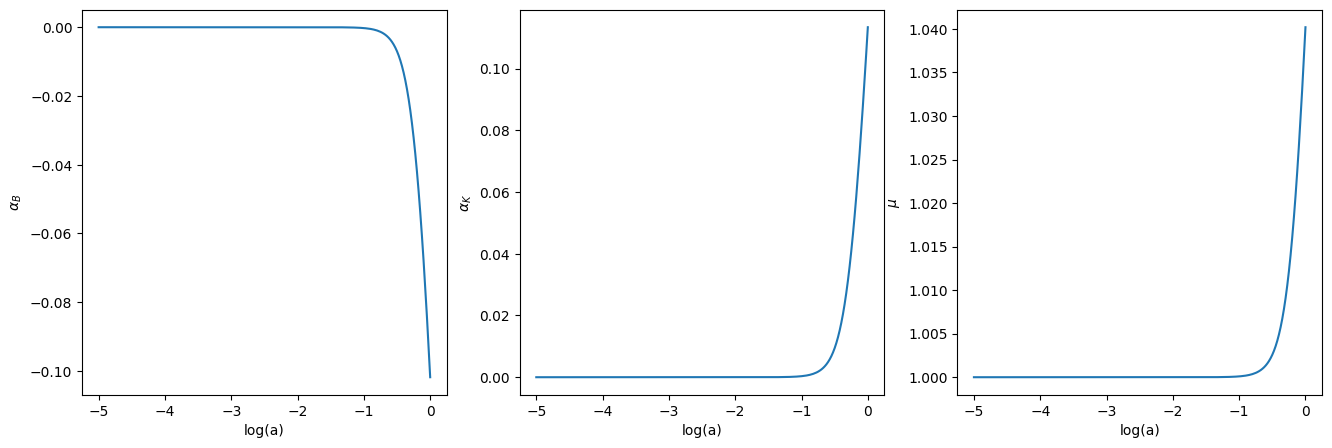

In [3]:
reference_cosmo = {
    "omega_m": 0.3,
    "w0": -0.838,
    "wa": -0.1,
    "cs2": 1,
    "cs2_a": 0,
    "alpha_K_0": 1,
}

log_a, alpha_B, alpha_K, mu, dalphaB_dloga = solve_alpha_B(aktype=alphaKtype.QUINT, **reference_cosmo)

fig, axs = plt.subplots(1, 3, figsize=(16, 5))
axs[0].plot(log_a, alpha_B)
axs[0].set_xlabel("log(a)")
axs[0].set_ylabel("$\\alpha_B$")
axs[1].plot(log_a, alpha_K)
axs[1].set_xlabel("log(a)")
axs[1].set_ylabel("$\\alpha_K$")
axs[2].plot(log_a, mu)
axs[2].set_xlabel("log(a)")
axs[2].set_ylabel("$\\mu$")

In [13]:
dalphaB_dloga = []
Omega_DE = []
dlogH_dloga = []
w_de = []
for i in range(len(log_a)):
    a = 10**log_a[i]
    bg = Bg(omega_m=reference_cosmo['omega_m'], w0=reference_cosmo['w0'], wa=reference_cosmo['wa'])
    
    wde, rhode, wtot, rhotot = get_bg_funcs(a, bg)
    w_de.append(wde)
    dlogH_dloga.append(-1.5*(1 + wtot))
    Omega_DE.append(rhode/rhotot)
    dalphaB_dloga.append(
        deriv(np.log(a), alpha_B[i], bg, alphaKtype.QUINT, reference_cosmo['alpha_K_0'], reference_cosmo['cs2'], reference_cosmo['cs2_a'])
    )
dalphaB_dloga = np.array(dalphaB_dloga)
Omega_DE = np.array(Omega_DE)
dlogH_dloga = np.array(dlogH_dloga)
w_de = np.array(w_de)

cs2N = (2 - alpha_B)*(-dlogH_dloga + 0.5*alpha_B) + 2*dlogH_dloga + 3*Omega_DE*(1 + w_de) + dalphaB_dloga
Dkin = alpha_K + 1.5*alpha_B**2

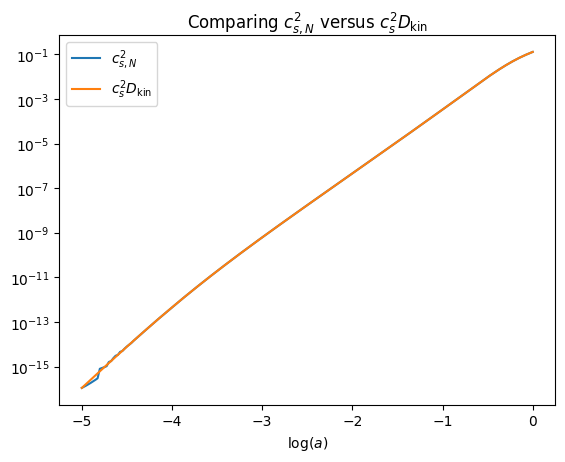

In [19]:
plt.semilogy(log_a, cs2N, label="$c_{s,N}^2$")
plt.semilogy(log_a, reference_cosmo['cs2']*Dkin, label="$c_{s}^2D_\\mathrm{kin}$")
plt.legend()
plt.xlabel("$\\log(a)$")
plt.title("Comparing $c_{s,N}^2$ versus $c_s^2D_\\mathrm{kin}$")
plt.savefig("plots/compare_cs2n_cs2Dkin.pdf")
# plt.ylabel("$\\log(a)$")